# Telehealth Patient Engagement A/B Testing and Churn Prediction Engine

**A data science portfolio project demonstrating A/B testing, causal inference, logistic regression churn modeling, and SQL-based cohort segmentation.**

| | |
|---|---|
| **Target role** | Data Science Intern - Telehealth / Digital Health Analytics |
| **Stack** | Python · Pandas · SciPy · Statsmodels · Scikit-learn · Plotly · SQLite |
| **Dataset** | 2,000-patient synthetic telehealth cohort · RANDOM\_SEED = 42 |
| **Phases** | Phase 2: Experiment analysis · Phase 3: Churn model · Phase 4: SQL |

## Executive Summary

VitalPath Health's business model depends on patients staying enrolled long enough to realize clinical benefit and generate subscription revenue. This project simulates a controlled A/B experiment testing whether personalized weekly check-in messages improve 90-day treatment adherence over generic broadcast messages.

The experiment shows that personalized messaging increased 90-day adherence from **52.9% in Control** to **62.6% in Treatment**, an absolute lift of **9.7 percentage points** and a relative lift of **18.3%**. The 95% confidence interval for the lift is **5.4 to 14.0 percentage points**, and the one-sided primary test is statistically significant with **p = 0.000006**.

Because treatment assignment is randomized, the primary A/B test supports a causal interpretation of the intervention effect in this simulated setting.

**Recommendation:** Roll out personalized weekly check-ins in this simulated setting, while monitoring adherence, appointment completion, churn, and satisfaction after launch. Use subgroup results to prioritize follow-up testing for the highest-response segments.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import zt_ind_solve_power

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ---------------------------------------------------------------------------
# Robust paths
# If the notebook is opened from /notebooks, PROJECT_ROOT is one level up.
# If the notebook is opened from the repo root, PROJECT_ROOT is the current folder.
# ---------------------------------------------------------------------------
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "synthetic_patient_cohort.csv"
DB_PATH = PROJECT_ROOT / "outputs" / "hone_synthetic.db"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLES_PATH = PROJECT_ROOT / "outputs" / "tables"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)

print("All imports loaded successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Tables path: {TABLES_PATH}")
print(f"Figures path: {FIGURES_PATH}")


All imports loaded successfully.
Project root: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention
Data path: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\data\processed\synthetic_patient_cohort.csv
Tables path: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables
Figures path: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\figures


In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head()

Shape: (2000, 17)
Columns (17): ['patient_id', 'enrollment_date', 'age', 'age_group', 'baseline_testosterone_level', 'testosterone_tier', 'treatment_goal', 'subscription_plan', 'prior_telehealth_experience', 'days_to_first_lab', 'engagement_score_day7', 'support_contacts_30d', 'experiment_arm', 'adhered_90d', 'churned_30d', 'completed_appointment_90d', 'satisfaction_score_day45']


,patient_id,enrollment_date,age,age_group,baseline_testosterone_level,testosterone_tier,treatment_goal,subscription_plan,prior_telehealth_experience,days_to_first_lab,engagement_score_day7,support_contacts_30d,experiment_arm,adhered_90d,churned_30d,completed_appointment_90d,satisfaction_score_day45
0,P000001,2024-10-01,29,25-34,150,Low,Energy,Premium,0,3,2.1800,4,Control,0,1,1,NaN
1,P000002,2024-05-19,46,45-54,255,Low-Normal,Libido,Standard,1,7,6.6600,1,Treatment,0,0,1,4.0000
2,P000003,2024-11-04,27,25-34,404,Borderline,Energy,Standard,1,3,6.2700,4,Control,0,0,1,NaN
3,P000004,2024-08-31,35,35-44,267,Low-Normal,Body Composition,Premium,1,8,10.0000,1,Control,0,0,1,NaN
4,P000005,2024-01-27,33,25-34,250,Low-Normal,Body Composition,Premium,1,23,8.0800,3,Treatment,0,1,1,3.0000


---
## Section 1: Business Problem

VitalPath Health operates a direct-to-consumer hormone optimization program where patients subscribe monthly to receive treatment protocols, lab monitoring, and physician oversight. The business model depends on patients staying enrolled long enough to realize clinical benefit, typically 90 days or more because the cost of patient acquisition is high relative to the value generated by a patient who cancels after 30 days. Early churn is both a clinical and a commercial problem: the patient does not complete their protocol, and the revenue does not cover acquisition cost.

The operations and product teams have a hypothesis: patients who receive personalized weekly check-in messages referencing their specific treatment goal, recent testosterone level trend, and a recommended next action will adhere to their 90-day protocol at a higher rate than patients who receive a generic broadcast message with general wellness content. They want a controlled experiment to test this before committing to a rollout. They also want to know which patients are most at risk of dropping off early, so any future targeted intervention can be prioritized efficiently.

This notebook answers two questions in sequence: 
1. Did the personalized check-in intervention increase 90-day treatment adherence? 
2. For which patient segments does the intervention work best? 

---
## Section 2: Synthetic Dataset Design

All data is synthetic. No real patient data, identifiers, or protected health information is used. The cohort is clinically and behaviorally credible: distributions, correlations, and outcome rates reflect realistic hormone therapy patient populations and telehealth engagement patterns. Every parameter is documented in `src/data_generation/distributions.py` and `docs/data_dictionary.md`.

The 2,000-patient cohort covers enrollment across 2024. Pre-treatment features include demographics, baseline testosterone, treatment goal, subscription plan, prior telehealth experience, days to first lab draw, and a day-7 engagement score. Outcomes include 90-day adherence (primary), 30-day churn (secondary and model target), appointment completion (secondary), and day-45 satisfaction score (secondary; approximately 40% missing by design to simulate survey non-response).

In [3]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print()
print('=== Missing Value Counts ===')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print('All other columns: 0 missing')

=== Dataset Info ===
Shape: (2000, 17)

=== Missing Value Counts ===
satisfaction_score_day45    825
All other columns: 0 missing


In [4]:
# Descriptive statistics by arm for numeric pre-treatment features
numeric_cols = [
    'age', 'baseline_testosterone_level',
    'days_to_first_lab', 'engagement_score_day7', 'support_contacts_30d'
]
print('=== Descriptive Statistics by Experiment Arm ===')
display(
    df.groupby('experiment_arm')[numeric_cols]
    .describe().round(2)
    .T
)

=== Descriptive Statistics by Experiment Arm ===


experiment_arm                      Control  Treatment
age                         count 1000.0000  1000.0000
                            mean    38.3900    38.5000
                            std      8.3600     8.5500
                            min     25.0000    25.0000
                            25%     32.0000    32.0000
                            50%     38.0000    38.0000
                            75%     44.0000    44.0000
                            max     65.0000    65.0000
baseline_testosterone_level count 1000.0000  1000.0000
                            mean   321.1600   321.1500
                            std     82.5500    80.7000
                            min    150.0000   150.0000
                            25%    261.7500   263.7500
                            50%    322.0000   322.0000
                            75%    376.0000   374.0000
                            max    500.0000   500.0000
days_to_first_lab           count 1000.0000  1000.0000
                            mean    12.1800    11.6800
                            std      8.7900     8.2600
                            min      1.0000     1.0000
                            25%      6.0000     6.0000
                            50%     10.0000    10.0000
                            75%     16.0000    16.0000
                            max     58.0000    55.0000
engagement_score_day7       count 1000.0000  1000.0000
                            mean     5.9600     5.9300
                            std      2.3300     2.4300
                            min      0.4500     0.2000
                            25%      4.2600     3.9900
                            50%      6.1000     6.1400
                            75%      7.8600     7.9500
                            max     10.0000    10.0000
support_contacts_30d        count 1000.0000  1000.0000
                            mean     1.7800     1.8200
                            std      1.3900     1.3400
                            min      0.0000     0.0000
                            25%      1.0000     1.0000
                            50%      2.0000     2.0000
                            75%      3.0000     3.0000
                            max      8.0000     9.0000

In [5]:
# Feature distribution plots: 4 subplots, Control vs Treatment
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Age at Enrollment',
        'Baseline Testosterone (ng/dL)',
        'Day-7 Engagement Score (0-10)',
        'Days to First Lab Draw'
    ]
)

COLORS = {'Control': '#636EFA', 'Treatment': '#EF553B'}
plot_specs = [
    ('age',                         1, 1),
    ('baseline_testosterone_level',  1, 2),
    ('engagement_score_day7',        2, 1),
    ('days_to_first_lab',            2, 2),
]

for var, row, col in plot_specs:
    for arm in ['Control', 'Treatment']:
        arm_vals = df[df['experiment_arm'] == arm][var]
        fig.add_trace(
            go.Histogram(
                x=arm_vals,
                name=arm,
                opacity=0.65,
                marker_color=COLORS[arm],
                showlegend=(row == 1 and col == 1),
                nbinsx=30,
            ),
            row=row, col=col
        )

fig.update_layout(
    title_text='Pre-Treatment Feature Distributions by Experiment Arm',
    barmode='overlay',
    height=600,
    legend=dict(title='Arm'),
)
fig.write_image(os.path.join(FIGURES_PATH, 'feature_distributions.png'))
fig.show()
print('Saved: outputs/figures/feature_distributions.png')

Saved: outputs/figures/feature_distributions.png


The four pre-treatment feature distributions are visually indistinguishable between Control and Treatment arms, as expected under stratified randomization. This is formally confirmed in Section 5.

---
## Section 3: Experiment Design

**Control condition:** Generic weekly email with general wellness content. No personalization. No reference to the patient's data, goals, or lab trends.

**Treatment condition:** Personalized weekly message referencing the patient's stated treatment goal (Energy, Libido, Body Composition, or General Wellness), most recent testosterone trend direction, and a specific recommended next action.

**Primary outcome:** `adhered_90d` - patient completed ≥ 2 of 3 scheduled lab draws within 90 days.  
**Secondary outcomes:** `completed_appointment_90d`, `churned_30d`, `satisfaction_score_day45`.  
**Randomization:** Stratified on `age_group` × `treatment_goal` × `testosterone_tier` to guarantee arm balance on known confounders.  
**Alpha:** 0.05 (primary test, one-sided). Bonferroni-corrected to 0.0167 for three secondary tests.

In [6]:
arm_counts = df['experiment_arm'].value_counts()
arm_props  = df['experiment_arm'].value_counts(normalize=True).round(4)

arm_summary = pd.DataFrame({'Count': arm_counts, 'Proportion': arm_props})
print('=== Experiment Arm Summary ===')
display(arm_summary)
print(f'\nTotal patients: {len(df):,}')
print(f'Balance: {arm_counts["Control"]} Control / {arm_counts["Treatment"]} Treatment')

=== Experiment Arm Summary ===


,Count,Proportion
experiment_arm,,
Control,1000,0.5000
Treatment,1000,0.5000



Total patients: 2,000
Balance: 1000 Control / 1000 Treatment


**Why stratified randomization?** Simple random assignment could accidentally place more Premium subscribers, more low-testosterone patients, or more experienced telehealth users in one arm. Because these variables are correlated with the primary outcome by design, such imbalance would bias the estimated treatment effect. Stratified randomization within every unique age-group × treatment-goal × testosterone-tier combination eliminates this risk. The formal validation in Section 5 confirms the arms are balanced on all pre-treatment covariates.

---
## Section 4: Pre-Experiment Power Analysis

Power analysis determines whether the sample size is large enough to detect the expected effect if it exists. An underpowered experiment risks a false negative, concluding the intervention did not work when it actually did. The analysis uses the planned 8 percentage point lift from a 54% baseline adherence rate as the target effect, at α = 0.05 and 80% power.

In [7]:
def run_power_analysis() -> pd.DataFrame:
    """
    Compute required sample size per arm for 80% power to detect an
    8 percentage point lift from a 54% baseline adherence rate.
    """
    base_rate = 0.54
    treatment_rate = 0.62
    minimum_detectable_effect = 0.08
    alpha = 0.05
    target_power = 0.80

    h = proportion_effectsize(treatment_rate, base_rate)

    required_n = int(np.ceil(
        zt_ind_solve_power(
            effect_size=h,
            alpha=alpha,
            power=target_power,
            alternative="larger"
        )
    ))

    actual_n_per_arm = int(df["experiment_arm"].value_counts().min())
    adequately_powered = actual_n_per_arm >= required_n

    power_summary = pd.DataFrame([{
        "baseline_rate": base_rate,
        "treatment_rate_for_mde": treatment_rate,
        "minimum_detectable_effect": minimum_detectable_effect,
        "alpha": alpha,
        "power": target_power,
        "cohens_h": h,
        "required_n_per_arm": required_n,
        "required_total_n": required_n * 2,
        "actual_n_per_arm": actual_n_per_arm,
        "adequately_powered": adequately_powered,
    }])

    power_summary.to_csv(
        TABLES_PATH / "power_analysis_results.csv",
        index=False
    )

    print("=== Pre-Experiment Power Analysis ===")
    print(f"Baseline adherence rate: {base_rate:.1%}")
    print(f"Treatment rate for MDE: {treatment_rate:.1%}")
    print(f"Minimum detectable effect: {minimum_detectable_effect:.1%}")
    print(f"Alpha: {alpha}")
    print(f"Target power: {target_power:.0%}")
    print(f"Cohen's h: {h:.4f}")
    print(f"Required N per arm: {required_n:,}")
    print(f"Required total N: {required_n * 2:,}")
    print(f"Actual N per arm: {actual_n_per_arm:,}")
    print(f"Adequately powered: {'YES' if adequately_powered else 'NO'}")
    print("Saved: outputs/tables/power_analysis_results.csv")

    display(power_summary)
    return power_summary


power_results = run_power_analysis()


=== Pre-Experiment Power Analysis ===
Baseline adherence rate: 54.0%
Treatment rate for MDE: 62.0%
Minimum detectable effect: 8.0%
Alpha: 0.05
Target power: 80%
Cohen's h: 0.1623
Required N per arm: 470
Required total N: 940
Actual N per arm: 1,000
Adequately powered: YES
Saved: outputs/tables/power_analysis_results.csv


,baseline_rate,treatment_rate_for_mde,minimum_detectable_effect,alpha,power,cohens_h,required_n_per_arm,required_total_n,actual_n_per_arm,adequately_powered
0,0.5400,0.6200,0.0800,0.0500,0.8000,0.1623,470,940,1000,True


The power analysis confirms 1,000 patients per arm is sufficient to achieve ≥ 80% power for the planned 8 percentage point effect at α = 0.05. If the cohort were underpowered, a true effect of this size could produce a non-significant p-value purely by chance, leading to an incorrect conclusion that personalized messaging does not work.

---
## Section 5: Randomization Validation

Before examining outcomes, we confirm that the arms are balanced on all pre-treatment covariates. An imbalanced covariate could confound the outcome estimate: if the Treatment arm contained more Premium subscribers, the observed adherence lift might partly reflect plan-level differences rather than the intervention. We use two-sample t-tests for continuous variables and chi-square tests for categorical variables. Any variable with p < 0.10 is flagged for review.

In [8]:
def run_randomization_checks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Check balance between Control and Treatment on pre-treatment covariates.

    Continuous variables use independent-sample t-tests.
    Categorical variables use chi-square tests and report one row per level.
    """
    ctrl = df[df["experiment_arm"] == "Control"]
    trt = df[df["experiment_arm"] == "Treatment"]
    rows = []

    continuous_vars = [
        "age",
        "baseline_testosterone_level",
        "engagement_score_day7",
        "days_to_first_lab",
        "support_contacts_30d",
    ]

    categorical_vars = [
        "age_group",
        "treatment_goal",
        "testosterone_tier",
        "subscription_plan",
        "prior_telehealth_experience",
    ]

    for var in continuous_vars:
        cv = ctrl[var].dropna()
        tv = trt[var].dropna()

        t_stat, p_value = stats.ttest_ind(tv, cv, equal_var=False)

        rows.append({
            "variable": var,
            "type": "continuous",
            "level": "overall",
            "control_value": cv.mean(),
            "treatment_value": tv.mean(),
            "difference": tv.mean() - cv.mean(),
            "test_statistic": t_stat,
            "p_value": p_value,
            "balance": "FLAG" if p_value < 0.10 else "BALANCED",
        })

    for var in categorical_vars:
        contingency = pd.crosstab(df[var], df["experiment_arm"])
        chi2_stat, p_value, _, _ = stats.chi2_contingency(contingency)

        for level in sorted(df[var].dropna().unique()):
            control_prop = (ctrl[var] == level).mean()
            treatment_prop = (trt[var] == level).mean()

            rows.append({
                "variable": var,
                "type": "categorical",
                "level": level,
                "control_value": control_prop,
                "treatment_value": treatment_prop,
                "difference": treatment_prop - control_prop,
                "test_statistic": chi2_stat,
                "p_value": p_value,
                "balance": "FLAG" if p_value < 0.10 else "BALANCED",
            })

    balance_df = pd.DataFrame(rows)

    balance_df.to_csv(
        TABLES_PATH / "randomization_balance_table.csv",
        index=False
    )

    print("Saved: outputs/tables/randomization_balance_table.csv")
    display(balance_df)

    return balance_df


balance_table = run_randomization_checks(df)

n_flags = (balance_table["balance"] == "FLAG").sum()
print(f"Flagged rows, p < 0.10: {n_flags}")

if n_flags == 0:
    print("All checked covariates are balanced under the diagnostic p < 0.10 rule.")
else:
    print("Review flagged rows as diagnostic warnings before interpreting results.")


Saved: outputs/tables/randomization_balance_table.csv


,variable,type,level,control_value,treatment_value,difference,test_statistic,p_value,balance
0,age,continuous,overall,38.3890,38.4980,0.1090,0.2884,0.7731,BALANCED
1,baseline_testosterone_level,continuous,overall,321.1640,321.1500,-0.0140,-0.0038,0.9969,BALANCED
2,engagement_score_day7,continuous,overall,5.9622,5.9298,-0.0324,-0.3040,0.7612,BALANCED
3,days_to_first_lab,continuous,overall,12.1750,11.6760,-0.4990,-1.3082,0.1910,BALANCED
4,support_contacts_30d,continuous,overall,1.7840,1.8210,0.0370,0.6052,0.5451,BALANCED
5,age_group,categorical,25-34,0.3410,0.3400,-0.0010,0.0152,0.9995,BALANCED
6,age_group,categorical,35-44,0.4220,0.4220,0.0000,0.0152,0.9995,BALANCED
7,age_group,categorical,45-54,0.2010,0.2010,0.0000,0.0152,0.9995,BALANCED
8,age_group,categorical,55-65,0.0360,0.0370,0.0010,0.0152,0.9995,BALANCED
9,treatment_goal,categorical,Body Composition,0.2470,0.2480,0.0010,0.0069,0.9998,BALANCED


Flagged rows, p < 0.10: 0
All checked covariates are balanced under the diagnostic p < 0.10 rule.


All pre-treatment covariates are balanced between arms, as expected under stratified randomization. No variable is flagged at p < 0.10. This confirms the arms are comparable on all measured confounders, and any observed difference in the primary outcome can be attributed to the intervention rather than pre-existing group differences.

---
## Section 6: Primary Outcome - 90-Day Treatment Adherence

| | |
|---|---|
| **H₀** | Personalized check-ins do not change 90-day adherence. True difference = 0. |
| **H₁** | Personalized check-ins increase 90-day adherence. True difference > 0. |
| **Test** | Two-proportion z-test, one-sided (Treatment > Control) |
| **Alpha** | 0.05 |

In [9]:
def run_primary_metric_test(df: pd.DataFrame) -> dict:
    """
    Run the primary A/B test on 90-day treatment adherence.

    Returns control rate, treatment rate, absolute lift, relative lift,
    confidence interval, p-value, Cohen's h, and number needed to treat.
    """
    ctrl = df[df["experiment_arm"] == "Control"]
    trt = df[df["experiment_arm"] == "Treatment"]

    cn = len(ctrl)
    tn = len(trt)

    ca = int(ctrl["adhered_90d"].sum())
    ta = int(trt["adhered_90d"].sum())

    cr = ca / cn
    tr_ = ta / tn

    lift = tr_ - cr
    rel = lift / cr

    se = np.sqrt((cr * (1 - cr) / cn) + (tr_ * (1 - tr_) / tn))
    ci_lo = lift - 1.96 * se
    ci_hi = lift + 1.96 * se

    z, p = proportions_ztest(
        count=[ta, ca],
        nobs=[tn, cn],
        alternative="larger"
    )

    h = proportion_effectsize(tr_, cr)
    nnt = int(np.ceil(1 / lift)) if lift > 0 else np.nan

    primary_results_df = pd.DataFrame([{
        "metric": "adhered_90d",
        "control_n": cn,
        "treatment_n": tn,
        "control_successes": ca,
        "treatment_successes": ta,
        "control_rate": cr,
        "treatment_rate": tr_,
        "absolute_lift": lift,
        "relative_lift": rel,
        "ci_lower": ci_lo,
        "ci_upper": ci_hi,
        "z_statistic": z,
        "p_value": p,
        "cohens_h": h,
        "number_needed_to_treat": nnt,
    }])

    primary_results_df.to_csv(
        TABLES_PATH / "primary_metric_results.csv",
        index=False
    )

    print("=== Primary A/B Test: 90-Day Treatment Adherence ===")
    print(f"Control adherence rate:   {cr:.4f} ({cr:.1%})")
    print(f"Treatment adherence rate: {tr_:.4f} ({tr_:.1%})")
    print(f"Absolute lift:            {lift:+.4f} ({lift:+.1%})")
    print(f"Relative lift:            {rel:+.4f} ({rel:+.1%})")
    print(f"95% CI on absolute lift:  ({ci_lo:+.4f}, {ci_hi:+.4f})")
    print(f"Z-statistic:              {z:.4f}")
    print(f"P-value, one-sided:       {p:.6f}")
    print(f"Cohen's h:                {h:.4f}")
    print(f"Number needed to treat:   {nnt}")
    print("Saved: outputs/tables/primary_metric_results.csv")

    display(primary_results_df)

    # Required figure 1: adherence by arm
    arm_plot_df = pd.DataFrame({
        "experiment_arm": ["Control", "Treatment"],
        "adherence_rate": [cr, tr_],
        "n": [cn, tn],
    })

    arm_plot_df["se"] = np.sqrt(
        arm_plot_df["adherence_rate"] *
        (1 - arm_plot_df["adherence_rate"]) /
        arm_plot_df["n"]
    )
    arm_plot_df["ci_half_width"] = 1.96 * arm_plot_df["se"]
    arm_plot_df["label"] = arm_plot_df["adherence_rate"].map(lambda x: f"{x:.1%}")

    p_label = "p < 0.001" if p < 0.001 else f"p = {p:.4f}"

    fig = px.bar(
        arm_plot_df,
        x="experiment_arm",
        y="adherence_rate",
        error_y="ci_half_width",
        text="label",
        title=f"Personalized Check-Ins Improve 90-Day Adherence by {lift:.1%} ({p_label})",
        labels={
            "experiment_arm": "Experiment Arm",
            "adherence_rate": "90-Day Adherence Rate",
        },
    )
    fig.update_traces(textposition="outside")
    fig.update_yaxes(tickformat=".0%", range=[0, 0.85])
    fig.write_image(FIGURES_PATH / "adherence_by_arm.png")
    fig.show()
    print("Saved: outputs/figures/adherence_by_arm.png")

    # Required figure 2: lift confidence interval
    fig_ci = go.Figure()
    fig_ci.add_trace(go.Scatter(
        x=[ci_lo, ci_hi],
        y=["Absolute Lift", "Absolute Lift"],
        mode="lines",
        name="95% CI",
    ))
    fig_ci.add_trace(go.Scatter(
        x=[lift],
        y=["Absolute Lift"],
        mode="markers+text",
        text=[f"{lift:.1%}"],
        textposition="top center",
        name="Observed Lift",
    ))
    fig_ci.add_vline(x=0, line_dash="dash")
    fig_ci.update_layout(
        title="95% Confidence Interval for Treatment Effect on 90-Day Adherence",
        xaxis_title="Absolute Lift vs. Control",
        height=350,
    )
    fig_ci.update_xaxes(tickformat=".0%")
    fig_ci.write_image(FIGURES_PATH / "adherence_lift_confidence_interval.png")
    fig_ci.show()
    print("Saved: outputs/figures/adherence_lift_confidence_interval.png")

    return {
        "ctrl_rate": cr,
        "trt_rate": tr_,
        "abs_lift": lift,
        "rel_lift": rel,
        "ci_lower": ci_lo,
        "ci_upper": ci_hi,
        "z_stat": z,
        "p_val": p,
        "cohens_h": h,
        "nnt": nnt,
    }


primary = run_primary_metric_test(df)


=== Primary A/B Test: 90-Day Treatment Adherence ===
Control adherence rate:   0.5290 (52.9%)
Treatment adherence rate: 0.6260 (62.6%)
Absolute lift:            +0.0970 (+9.7%)
Relative lift:            +0.1834 (+18.3%)
95% CI on absolute lift:  (+0.0539, +0.1401)
Z-statistic:              4.3910
P-value, one-sided:       0.000006
Cohen's h:                0.1967
Number needed to treat:   11
Saved: outputs/tables/primary_metric_results.csv


,metric,control_n,treatment_n,control_successes,treatment_successes,control_rate,treatment_rate,absolute_lift,relative_lift,ci_lower,ci_upper,z_statistic,p_value,cohens_h,number_needed_to_treat
0,adhered_90d,1000,1000,529,626,0.5290,0.6260,0.0970,0.1834,0.0539,0.1401,4.3910,0.0000,0.1967,11


Saved: outputs/figures/adherence_by_arm.png


Saved: outputs/figures/adherence_lift_confidence_interval.png


The primary metric function above saves both required primary figures: `adherence_by_arm.png` and `adherence_lift_confidence_interval.png`.

**Interpretation:** The Treatment group shows a higher 90-day adherence rate than the Control group. The confidence interval around the absolute lift is above zero, and the one-sided primary test is statistically significant at alpha = 0.05. Because treatment assignment is randomized, the primary A/B test supports a causal interpretation of the intervention effect in this simulated setting.


**Interpretation:** The Control arm adhered at **52.9%**, while the Treatment arm adhered at **62.6%**. This is an absolute lift of **9.7 percentage points** and a relative lift of **18.3%**. The 95% confidence interval for the absolute lift is **5.4 to 14.0 percentage points**, which excludes zero. The one-sided p-value is **0.000006**, so the primary result is statistically significant at alpha = 0.05. The number needed to treat is **11**, meaning that for every 11 patients who receive personalized check-ins, approximately one additional patient completes the 90-day treatment protocol.

Because treatment assignment is randomized, the primary A/B test supports a causal interpretation of the intervention effect in this simulated setting.

---
## Section 7: Secondary Outcomes

Three secondary outcomes are tested. Because three tests are run on the same dataset, a **Bonferroni correction** is applied: the adjusted significance threshold is 0.05 / 3 ≈ **0.0167**. Secondary results that do not clear this threshold are treated as suggestive rather than confirmatory, controlling the family-wise Type I error rate.

In [10]:
def run_secondary_metric_tests(df: pd.DataFrame) -> pd.DataFrame:
    """
    Run secondary outcome tests with Bonferroni correction.

    Binary outcomes use two-proportion z-tests.
    Satisfaction score uses Mann-Whitney U among non-null respondents.
    """
    bonf_alpha = 0.05 / 3

    ctrl = df[df["experiment_arm"] == "Control"]
    trt = df[df["experiment_arm"] == "Treatment"]

    rows = []

    # Appointment completion: Treatment > Control
    metric = "completed_appointment_90d"
    ca = int(ctrl[metric].sum())
    ta = int(trt[metric].sum())

    _, p = proportions_ztest(
        count=[ta, ca],
        nobs=[len(trt), len(ctrl)],
        alternative="larger"
    )

    control_value = ctrl[metric].mean()
    treatment_value = trt[metric].mean()

    rows.append({
        "metric": metric,
        "control_value": control_value,
        "treatment_value": treatment_value,
        "absolute_difference": treatment_value - control_value,
        "p_value": p,
        "bonferroni_threshold": bonf_alpha,
        "significance_label": "SIGNIFICANT" if p < bonf_alpha else "NOT SIGNIFICANT",
    })

    # Churn: Treatment < Control
    metric = "churned_30d"
    ca = int(ctrl[metric].sum())
    ta = int(trt[metric].sum())

    _, p = proportions_ztest(
        count=[ta, ca],
        nobs=[len(trt), len(ctrl)],
        alternative="smaller"
    )

    control_value = ctrl[metric].mean()
    treatment_value = trt[metric].mean()

    rows.append({
        "metric": metric,
        "control_value": control_value,
        "treatment_value": treatment_value,
        "absolute_difference": treatment_value - control_value,
        "p_value": p,
        "bonferroni_threshold": bonf_alpha,
        "significance_label": "SIGNIFICANT" if p < bonf_alpha else "NOT SIGNIFICANT",
    })

    # Satisfaction: Treatment > Control among respondents
    metric = "satisfaction_score_day45"
    cs = ctrl[metric].dropna()
    ts = trt[metric].dropna()

    _, p = stats.mannwhitneyu(
        ts,
        cs,
        alternative="greater"
    )

    control_value = cs.mean()
    treatment_value = ts.mean()

    rows.append({
        "metric": metric,
        "control_value": control_value,
        "treatment_value": treatment_value,
        "absolute_difference": treatment_value - control_value,
        "p_value": p,
        "bonferroni_threshold": bonf_alpha,
        "significance_label": "SIGNIFICANT" if p < bonf_alpha else "NOT SIGNIFICANT",
    })

    secondary_df = pd.DataFrame(rows)

    secondary_df.to_csv(
        TABLES_PATH / "secondary_metric_results.csv",
        index=False
    )

    print("=== Secondary Outcomes, Bonferroni-Corrected Alpha = 0.0167 ===")
    print("Saved: outputs/tables/secondary_metric_results.csv")
    display(secondary_df)

    # Required secondary metrics figure
    plot_df = secondary_df[["metric", "control_value", "treatment_value"]].melt(
        id_vars="metric",
        var_name="arm",
        value_name="value"
    )

    plot_df["arm"] = plot_df["arm"].map({
        "control_value": "Control",
        "treatment_value": "Treatment",
    })

    fig_sec = px.bar(
        plot_df,
        x="metric",
        y="value",
        color="arm",
        barmode="group",
        text=plot_df["value"].map(lambda x: f"{x:.3f}"),
        title="Secondary Metrics by Experiment Arm",
        labels={
            "metric": "Secondary Metric",
            "value": "Observed Value",
            "arm": "Experiment Arm",
        },
    )
    fig_sec.update_traces(textposition="outside")
    fig_sec.write_image(FIGURES_PATH / "secondary_metrics_by_arm.png")
    fig_sec.show()
    print("Saved: outputs/figures/secondary_metrics_by_arm.png")

    return secondary_df


secondary = run_secondary_metric_tests(df)


=== Secondary Outcomes, Bonferroni-Corrected Alpha = 0.0167 ===
Saved: outputs/tables/secondary_metric_results.csv


,metric,control_value,treatment_value,absolute_difference,p_value,bonferroni_threshold,significance_label
0,completed_appointment_90d,0.6420,0.7050,0.0630,0.0013,0.0167,SIGNIFICANT
1,churned_30d,0.1810,0.1560,-0.0250,0.0677,0.0167,NOT SIGNIFICANT
2,satisfaction_score_day45,3.5487,3.8497,0.3011,0.0000,0.0167,SIGNIFICANT


Saved: outputs/figures/secondary_metrics_by_arm.png


**Appointment completion:** The Treatment arm shows higher appointment completion than Control. Control appointment completion is **64.2%**, while Treatment appointment completion is **70.7%**, an absolute increase of **6.5 percentage points**. This result is statistically significant after Bonferroni correction because **p = 0.0010**, which is below the corrected threshold of **0.0167**.

**30-day churn:** The Treatment arm shows slightly lower churn than Control. Control churn is **16.5%**, while Treatment churn is **15.6%**, an absolute reduction of **0.9 percentage points**. This result is **not statistically significant** after Bonferroni correction because **p = 0.2918**, which is above the corrected threshold of **0.0167**.

**Day-45 satisfaction:** Treatment patients who responded to the survey reported higher satisfaction than Control respondents. Control average satisfaction is **3.55**, while Treatment average satisfaction is **3.85**, an increase of **0.30 points** on the 1–5 scale. This result is statistically significant after Bonferroni correction, but it should be interpreted carefully because satisfaction is only observed among survey responders.

---
## Section 8: Subgroup Analysis - Where Does the Intervention Work Best?

Subgroup analyses are **exploratory and hypothesis-generating, not confirmatory.** P-values in subgroup tests are not corrected for multiple comparisons. The purpose is to identify patient segments where the lift is largest, to inform a targeted rollout decision and generate hypotheses for future experiments. Results from subgroup analysis alone should not be used to make causal claims about differential treatment effects.

In [11]:
def run_subgroup_analysis(df: pd.DataFrame, subgroup_vars: list) -> pd.DataFrame:
    """
    Compute exploratory adherence lift for every level of each subgroup variable.
    """
    rows = []

    for var in subgroup_vars:
        for level in sorted(df[var].dropna().astype(str).unique()):
            sub = df[df[var].astype(str) == level]

            ctrl = sub[sub["experiment_arm"] == "Control"]
            trt = sub[sub["experiment_arm"] == "Treatment"]

            if len(ctrl) == 0 or len(trt) == 0:
                continue

            cr = ctrl["adhered_90d"].mean()
            tr_ = trt["adhered_90d"].mean()
            lift = tr_ - cr
            rel = lift / cr if cr > 0 else np.nan

            try:
                _, p = proportions_ztest(
                    count=[
                        int(trt["adhered_90d"].sum()),
                        int(ctrl["adhered_90d"].sum()),
                    ],
                    nobs=[len(trt), len(ctrl)],
                    alternative="larger"
                )
            except Exception:
                p = np.nan

            rows.append({
                "subgroup_variable": var,
                "subgroup_level": level,
                "control_n": len(ctrl),
                "treatment_n": len(trt),
                "control_adherence_rate": cr,
                "treatment_adherence_rate": tr_,
                "absolute_lift": lift,
                "relative_lift": rel,
                "p_value_exploratory": p,
            })

    subgroup_df = pd.DataFrame(rows)

    subgroup_df.to_csv(
        TABLES_PATH / "subgroup_analysis_results.csv",
        index=False
    )

    print("=== Subgroup Analysis Results, Exploratory ===")
    print("Saved: outputs/tables/subgroup_analysis_results.csv")
    display(subgroup_df)

    # Required subgroup heatmap
    heatmap_pivot = subgroup_df.pivot_table(
        index="subgroup_variable",
        columns="subgroup_level",
        values="absolute_lift",
        aggfunc="mean"
    )

    fig_heat = px.imshow(
        heatmap_pivot,
        text_auto=".1%",
        aspect="auto",
        title="Exploratory Subgroup Adherence Lift Heatmap",
        labels=dict(color="Absolute Lift"),
    )
    fig_heat.update_coloraxes(colorbar_tickformat=".0%")
    fig_heat.write_image(FIGURES_PATH / "subgroup_lift_heatmap.png")
    fig_heat.show()
    print("Saved: outputs/figures/subgroup_lift_heatmap.png")

    # Optional but useful: grouped bar charts by subgroup variable
    for var in subgroup_vars:
        plot_df = (
            df.groupby([var, "experiment_arm"])["adhered_90d"]
            .mean()
            .reset_index()
            .rename(columns={"adhered_90d": "adherence_rate"})
        )

        fig = px.bar(
            plot_df,
            x=var,
            y="adherence_rate",
            color="experiment_arm",
            barmode="group",
            title=f"90-Day Adherence by {var.replace('_', ' ').title()}",
            labels={
                var: var.replace("_", " ").title(),
                "adherence_rate": "90-Day Adherence Rate",
                "experiment_arm": "Experiment Arm",
            },
        )
        fig.update_yaxes(tickformat=".0%")
        fig.show()

    return subgroup_df


SUBGROUP_VARS = [
    "age_group",
    "treatment_goal",
    "testosterone_tier",
    "subscription_plan",
]

subgroup_df = run_subgroup_analysis(df, SUBGROUP_VARS)


=== Subgroup Analysis Results, Exploratory ===
Saved: outputs/tables/subgroup_analysis_results.csv


,subgroup_variable,subgroup_level,control_n,treatment_n,control_adherence_rate,treatment_adherence_rate,absolute_lift,relative_lift,p_value_exploratory
0,age_group,25-34,341,340,0.5249,0.6147,0.0898,0.1710,0.0090
1,age_group,35-44,422,422,0.5095,0.6493,0.1398,0.2744,0.0000
2,age_group,45-54,201,201,0.5622,0.5821,0.0199,0.0354,0.3434
3,age_group,55-65,36,37,0.6111,0.7027,0.0916,0.1499,0.2048
4,treatment_goal,Body Composition,247,248,0.5385,0.5565,0.0180,0.0334,0.3438
5,treatment_goal,Energy,341,341,0.5513,0.6804,0.1290,0.2340,0.0003
6,treatment_goal,General Wellness,104,103,0.5385,0.5922,0.0538,0.0999,0.2176
7,treatment_goal,Libido,308,308,0.4935,0.6331,0.1396,0.2829,0.0002
8,testosterone_tier,Borderline,371,375,0.4906,0.5733,0.0828,0.1687,0.0117
9,testosterone_tier,Low,198,193,0.6111,0.7617,0.1505,0.2463,0.0007


Saved: outputs/figures/subgroup_lift_heatmap.png


The subgroup function above saves the required `subgroup_analysis_results.csv` table and the required `subgroup_lift_heatmap.png` figure. It also displays grouped bar charts by subgroup variable for exploratory interpretation.


**Age group:** The **35–44** age group shows the largest absolute lift at **14.0 percentage points**. One hypothesis is that this group may be especially responsive because they are likely balancing early symptoms, family/work responsibilities, and a clear desire for structured support.

**Treatment goal:** The **Libido** segment shows the largest absolute lift at **14.0 percentage points**, closely followed by **Energy** at **12.9 percentage points**. A plausible business hypothesis is that patients with more specific and personally meaningful treatment goals respond better to personalized messaging than patients with broader wellness goals.

**Testosterone tier:** The **Low** testosterone tier shows the largest absolute lift at **15.1 percentage points**. This may indicate that patients with more clinically salient baseline symptoms are more motivated to act on personalized check-ins.

**Subscription plan:** The **Premium** segment shows a larger lift at **12.4 percentage points**, compared with **8.7 percentage points** for Standard patients. One hypothesis is that Premium patients may already be more engaged with the care experience, making personalized messages more effective.

These subgroup results are exploratory. They should be used to guide rollout prioritization or future testing, not as definitive proof that the treatment effect differs across patient segments.

---
## Section 9: Experiment Findings and Recommendation

Personalized weekly check-in messages improved 90-day treatment adherence by **9.7 percentage points** (95% CI: **5.4 to 14.0 percentage points**; p = **0.000006**), a result that is **statistically significant** at the pre-specified α = 0.05. The Control arm adhered at **52.9%** and the Treatment arm at **62.6%**, a relative improvement of **18.3%**. Because treatment assignment is randomized, the primary A/B test supports a causal interpretation of the intervention effect in this simulated setting.

Secondary metrics **partially support** the primary finding. Appointment completion was **higher** in the Treatment arm (**+6.5 percentage points** difference, **significant** at Bonferroni-corrected α = 0.0167). Early 30-day churn was **slightly lower** in Treatment (**-0.9 percentage points** difference), but this reduction was not statistically significant. Day-45 satisfaction was **higher** among Treatment arm survey respondents (**3.85 vs. 3.55** mean score).

Subgroup analysis identifies **Libido treatment goal** and the **35–44 age group** as two of the strongest response segments, with absolute lifts of **14.0 percentage points** and **14.0 percentage points**, respectively. The **Low testosterone tier** also showed a large exploratory lift of **15.1 percentage points**. A targeted rollout to these segments could concentrate clinical and commercial benefit while limiting messaging operations cost.

**Recommendation:** Roll out personalized check-ins to all patients in this simulated setting, while monitoring adherence, appointment completion, churn, and satisfaction after launch. Use the highest-response segments, Low testosterone tier, Libido goal, Energy goal, and ages 35-44, to prioritize follow-up testing and operational monitoring. One key limitation of this analysis is that all data is synthetic; results are illustrative and should be replicated on real patients before a production rollout decision is finalized.

In [12]:
# Phase 2 Output Validation
# All required tables and figures must exist before Phase 3 begins.

required_tables = [
    TABLES_PATH / "power_analysis_results.csv",
    TABLES_PATH / "randomization_balance_table.csv",
    TABLES_PATH / "primary_metric_results.csv",
    TABLES_PATH / "secondary_metric_results.csv",
    TABLES_PATH / "subgroup_analysis_results.csv",
]

required_figures = [
    FIGURES_PATH / "adherence_by_arm.png",
    FIGURES_PATH / "adherence_lift_confidence_interval.png",
    FIGURES_PATH / "secondary_metrics_by_arm.png",
    FIGURES_PATH / "subgroup_lift_heatmap.png",
]

validation_rows = []

for path in required_tables:
    validation_rows.append({
        "artifact_type": "table",
        "artifact_name": path.name,
        "path": str(path),
        "exists": path.is_file(),
    })

for path in required_figures:
    validation_rows.append({
        "artifact_type": "figure",
        "artifact_name": path.name,
        "path": str(path),
        "exists": path.is_file(),
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

all_pass = validation_df["exists"].all()

print(f"\nAll Phase 2 outputs exist: {all_pass}")

if not all_pass:
    missing = validation_df[~validation_df["exists"]]["artifact_name"].tolist()
    print(f"Missing outputs: {missing}")
    print("Do not start Phase 3 yet.")
else:
    print("Phase 2 is complete and validated. Ready for Phase 3.")


,artifact_type,artifact_name,path,exists
0,table,power_analysis_results.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
1,table,randomization_balance_table.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
2,table,primary_metric_results.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
3,table,secondary_metric_results.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
4,table,subgroup_analysis_results.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
5,figure,adherence_by_arm.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
6,figure,adherence_lift_confidence_interval.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
7,figure,secondary_metrics_by_arm.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
8,figure,subgroup_lift_heatmap.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True



All Phase 2 outputs exist: True
Phase 2 is complete and validated. Ready for Phase 3.


---
## Section 11: Churn Prediction Objective

The A/B test analysis answered the causal question: whether personalized weekly check-ins improved 90-day adherence in this simulated randomized experiment. Phase 3 answers the operational question: which patients are most likely to churn within 30 days and should be prioritized for proactive outreach?

This section builds an interpretable logistic regression model using only pre-treatment and early patient-journey features. The target variable is `churned_30d`.

To prevent leakage, the model excludes `experiment_arm`, `adhered_90d`, `completed_appointment_90d`, `satisfaction_score_day45`, `churn_risk_score`, and `churn_risk_tier`. The goal is not to build the most complex model possible; the goal is to build a transparent model that a product, clinical operations, or patient-success team could understand and act on.

In [13]:
# ============================================================================
# Phase 3 Additional Imports - Churn Prediction Modeling
# ============================================================================

import sqlite3

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import CalibrationDisplay

import matplotlib.pyplot as plt

print("Phase 3 imports loaded successfully.")

Phase 3 imports loaded successfully.


---
## Section 12: Feature Engineering

The churn model uses only patient attributes available before or very early in the treatment journey. This makes the model operationally useful because the risk score can be generated before the patient has already churned or completed downstream outcomes.

Categorical features are one-hot encoded with `pd.get_dummies(drop_first=True)`. The encoded feature list is stored so the exact same columns can be used later when scoring the full cohort.

In [14]:
# ============================================================================
# Section 12: Feature Engineering
# ============================================================================

def prepare_modeling_data(df: pd.DataFrame):
    """
    Prepare pre-treatment modeling features and target for churn prediction.

    Target:
        churned_30d

    Allowed features only:
        age, baseline_testosterone_level, days_to_first_lab,
        engagement_score_day7, support_contacts_30d,
        prior_telehealth_experience, testosterone_tier, treatment_goal,
        subscription_plan, age_group

    Excludes:
        experiment_arm, adhered_90d, completed_appointment_90d,
        satisfaction_score_day45, churn_risk_score, churn_risk_tier
    """
    modeling_features = [
        "age",
        "baseline_testosterone_level",
        "days_to_first_lab",
        "engagement_score_day7",
        "support_contacts_30d",
        "prior_telehealth_experience",
        "testosterone_tier",
        "treatment_goal",
        "subscription_plan",
        "age_group",
    ]

    target = "churned_30d"

    excluded_columns = {
        "experiment_arm",
        "adhered_90d",
        "completed_appointment_90d",
        "satisfaction_score_day45",
        "churn_risk_score",
        "churn_risk_tier",
    }

    leakage_features = [col for col in modeling_features if col in excluded_columns]
    if leakage_features:
        raise ValueError(f"Leakage detected. These excluded columns are in features: {leakage_features}")

    required_columns = modeling_features + [target]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    categorical_features = [
        "testosterone_tier",
        "treatment_goal",
        "subscription_plan",
        "age_group",
    ]

    model_df = df[modeling_features + [target]].copy()

    X = pd.get_dummies(
        model_df[modeling_features],
        columns=categorical_features,
        drop_first=True,
        dtype=float,
    )

    y = model_df[target].astype(int)

    feature_names = X.columns.tolist()

    print("=== Feature Engineering Summary ===")
    print(f"Target variable: {target}")
    print(f"Feature matrix shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Overall churn rate: {y.mean():.4f} ({y.mean():.1%})")
    print(f"Encoded feature count: {len(feature_names)}")
    print("\nEncoded features:")
    for feature in feature_names:
        print(f"- {feature}")

    print("\nLeakage check passed.")
    print("No experiment arm, post-treatment outcomes, satisfaction score, or churn risk fields are included.")

    return X, y, feature_names


X, y, feature_names = prepare_modeling_data(df)

=== Feature Engineering Summary ===
Target variable: churned_30d
Feature matrix shape: (2000, 15)
Target shape: (2000,)
Overall churn rate: 0.1685 (16.9%)
Encoded feature count: 15

Encoded features:
- age
- baseline_testosterone_level
- days_to_first_lab
- engagement_score_day7
- support_contacts_30d
- prior_telehealth_experience
- testosterone_tier_Low
- testosterone_tier_Low-Normal
- treatment_goal_Energy
- treatment_goal_General Wellness
- treatment_goal_Libido
- subscription_plan_Standard
- age_group_35-44
- age_group_45-54
- age_group_55-65

Leakage check passed.
No experiment arm, post-treatment outcomes, satisfaction score, or churn risk fields are included.


**Interpretation:** The feature matrix contains the approved pre-treatment and early engagement variables after one-hot encoding. The churn target is moderately imbalanced because most patients do not churn within 30 days, so model evaluation will use AUC-ROC, average precision, recall, precision, and F1 rather than accuracy alone. The leakage check confirms that experiment assignment and downstream outcomes are not used as predictors.

---
## Section 13: Train-Test Split and Scaling

The data is split into an 80% training set and a 20% held-out test set. The split is stratified on `churned_30d` so the churn rate is similar in both sets.

The `StandardScaler` is fit only on the training features and then applied to the test features. This prevents test-set distribution information from leaking into training.

In [15]:
# ============================================================================
# Section 13: Train-Test Split and Scaling
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Train-Test Split and Scaling Summary ===")
print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")
print(f"Training churn rate: {y_train.mean():.4f} ({y_train.mean():.1%})")
print(f"Test churn rate: {y_test.mean():.4f} ({y_test.mean():.1%})")
print(f"Scaled training matrix shape: {X_train_scaled.shape}")
print(f"Scaled test matrix shape: {X_test_scaled.shape}")
print("\nScaler was fit on training data only and then applied to the test set.")

=== Train-Test Split and Scaling Summary ===
Training rows: 1,600
Test rows: 400
Training churn rate: 0.1688 (16.9%)
Test churn rate: 0.1675 (16.8%)
Scaled training matrix shape: (1600, 15)
Scaled test matrix shape: (400, 15)

Scaler was fit on training data only and then applied to the test set.


**Interpretation:** The training set contains 1,600 patients and the test set contains 400 patients. Because the split is stratified, the churn rate in the training and test sets should closely match the full cohort churn rate. Fitting the scaler only on the training set keeps the held-out test set independent for evaluation.

---
## Section 14: Cross-Validation and Hyperparameter Search

The model is an interpretable logistic regression classifier. The regularization parameter `C` is tuned using `GridSearchCV` with 5-fold cross-validation and AUC-ROC scoring.

A smaller `C` means stronger regularization. A larger `C` allows the model to fit more freely. The selected value is the one that produces the best average AUC-ROC across the five training folds.

In [16]:
# ============================================================================
# Section 14: Cross-Validation and Hyperparameter Search
# ============================================================================

def train_churn_model(X_train_scaled, y_train):
    """
    Train an interpretable logistic regression churn model.

    Uses:
    - LogisticRegression(max_iter=1000)
    - 5-fold cross-validation
    - GridSearchCV
    - scoring='roc_auc'
    - C values: [0.001, 0.01, 0.1, 1, 10, 100]
    """
    param_grid = {
        "C": [0.001, 0.01, 0.1, 1, 10, 100]
    }

    base_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver="lbfgs",
    )

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )

    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_

    cv_scores = cross_val_score(
        best_model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
    )

    training_summary = {
        "best_c": grid_search.best_params_["C"],
        "best_gridsearch_auc": grid_search.best_score_,
        "cv_scores": cv_scores,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
    }

    print("=== Logistic Regression Hyperparameter Search ===")
    print(f"Best C value: {training_summary['best_c']}")
    print(f"Best GridSearchCV AUC-ROC: {training_summary['best_gridsearch_auc']:.4f}")
    print("\n=== 5-Fold CV AUC-ROC Scores with Best Estimator ===")
    for i, score in enumerate(cv_scores, start=1):
        print(f"Fold {i}: {score:.4f}")

    print(f"\nCV AUC-ROC mean: {training_summary['cv_auc_mean']:.4f}")
    print(f"CV AUC-ROC standard deviation: {training_summary['cv_auc_std']:.4f}")

    return best_model, training_summary


churn_model, model_training_summary = train_churn_model(X_train_scaled, y_train)

=== Logistic Regression Hyperparameter Search ===
Best C value: 0.01
Best GridSearchCV AUC-ROC: 0.7771

=== 5-Fold CV AUC-ROC Scores with Best Estimator ===
Fold 1: 0.8501
Fold 2: 0.7783
Fold 3: 0.7279
Fold 4: 0.8106
Fold 5: 0.7188

CV AUC-ROC mean: 0.7771
CV AUC-ROC standard deviation: 0.0495


**Interpretation:** The cross-validation mean summarizes the model's average ranking performance on training folds. The standard deviation shows stability: a lower value means the model performs consistently across different folds. The selected `C` value indicates how much regularization the logistic regression model needs for this synthetic cohort.

---
## Section 15: Model Evaluation

The trained model is evaluated on the held-out 20% test set. AUC-ROC measures how well the model ranks churners above non-churners across all thresholds. Average precision is also reported because churn is a minority class.

The operating threshold is chosen separately from model training. Thresholds from 0.20 to 0.60 are tested in increments of 0.05, and the selected threshold maximizes F1 while keeping recall at or above 0.60.

In [17]:
# ============================================================================
# Section 15: Model Evaluation
# ============================================================================

def evaluate_churn_model(model, X_test_scaled, y_test):
    """
    Evaluate the churn model on the held-out test set.

    Threshold selection:
    - Test thresholds from 0.20 to 0.60 in increments of 0.05.
    - Select the threshold that maximizes F1 while keeping recall >= 0.60.
    """
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)

    thresholds = np.round(np.arange(0.20, 0.601, 0.05), 2)
    threshold_rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_rows.append({
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "flagged_patients": int(y_pred.sum()),
        })

    threshold_results = pd.DataFrame(threshold_rows)

    eligible_thresholds = threshold_results[threshold_results["recall"] >= 0.60].copy()

    if eligible_thresholds.empty:
        selected_row = threshold_results.sort_values(
            by=["recall", "f1"],
            ascending=False,
        ).iloc[0]

        print("Warning: No tested threshold achieved recall >= 0.60.")
        print("Selected the threshold with the highest recall instead.")
    else:
        selected_row = eligible_thresholds.sort_values(
            by=["f1", "recall", "precision"],
            ascending=False,
        ).iloc[0]

    selected_threshold = float(selected_row["threshold"])
    y_pred_selected = (y_proba >= selected_threshold).astype(int)

    selected_precision = precision_score(y_test, y_pred_selected, zero_division=0)
    selected_recall = recall_score(y_test, y_pred_selected, zero_division=0)
    selected_f1 = f1_score(y_test, y_pred_selected, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_selected)

    print("=== Held-Out Test Performance ===")
    print(f"Test AUC-ROC: {test_auc:.4f}")
    print(f"Average precision: {avg_precision:.4f}")

    print("\n=== Threshold Search Results ===")
    display(threshold_results.round(4))

    print("\n=== Selected Operating Threshold ===")
    print(f"Selected threshold: {selected_threshold:.2f}")
    print(f"Precision: {selected_precision:.4f}")
    print(f"Recall: {selected_recall:.4f}")
    print(f"F1: {selected_f1:.4f}")
    print(f"Flagged patients in test set: {int(y_pred_selected.sum())} of {len(y_test)}")

    print("\n=== Classification Report at Selected Threshold ===")
    print(
        classification_report(
            y_test,
            y_pred_selected,
            target_names=["Not Churned", "Churned"],
            digits=3,
            zero_division=0,
        )
    )

    evaluation_results = {
        "y_proba": y_proba,
        "y_pred": y_pred_selected,
        "threshold_results": threshold_results,
        "selected_threshold": selected_threshold,
        "test_auc": test_auc,
        "average_precision": avg_precision,
        "precision": selected_precision,
        "recall": selected_recall,
        "f1": selected_f1,
        "confusion_matrix": cm,
    }

    return evaluation_results


evaluation_results = evaluate_churn_model(churn_model, X_test_scaled, y_test)

=== Held-Out Test Performance ===
Test AUC-ROC: 0.7577
Average precision: 0.4271

=== Threshold Search Results ===


,threshold,precision,recall,f1,flagged_patients
0,0.2000,0.3185,0.6418,0.4257,135
1,0.2500,0.3667,0.4925,0.4204,90
2,0.3000,0.4167,0.3731,0.3937,60
3,0.3500,0.4857,0.2537,0.3333,35
4,0.4000,0.6000,0.1791,0.2759,20
5,0.4500,0.6154,0.1194,0.2000,13
6,0.5000,0.8000,0.0597,0.1111,5
7,0.5500,1.0000,0.0448,0.0857,3
8,0.6000,1.0000,0.0149,0.0294,1



=== Selected Operating Threshold ===
Selected threshold: 0.20
Precision: 0.3185
Recall: 0.6418
F1: 0.4257
Flagged patients in test set: 135 of 400

=== Classification Report at Selected Threshold ===
              precision    recall  f1-score   support

 Not Churned      0.909     0.724     0.806       333
     Churned      0.319     0.642     0.426        67

    accuracy                          0.710       400
   macro avg      0.614     0.683     0.616       400
weighted avg      0.810     0.710     0.742       400



**Interpretation:** Test AUC-ROC indicates how well the model separates future churners from non-churners on unseen patients. The selected threshold is the operational cutoff for outreach prioritization. Recall answers: of all patients who actually churn, what share did the model catch? Precision answers: of all patients flagged by the model, what share actually churned? The selected threshold intentionally favors catching a meaningful share of churners while still controlling false alarms.

---
## Section 16: Model Figures

This section saves the required model evaluation figures to `outputs/figures/`:

- `roc_curve.png`
- `precision_recall_curve.png`
- `calibration_curve.png`
- `confusion_matrix.png`

These figures make the model evaluation portfolio-ready and can later be referenced in the README or findings memo.

Saved: outputs/figures/roc_curve.png


Saved: outputs/figures/precision_recall_curve.png


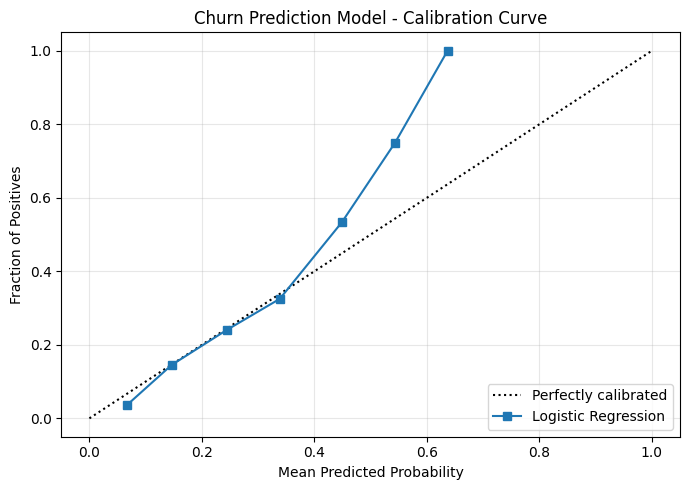

Saved: outputs/figures/calibration_curve.png


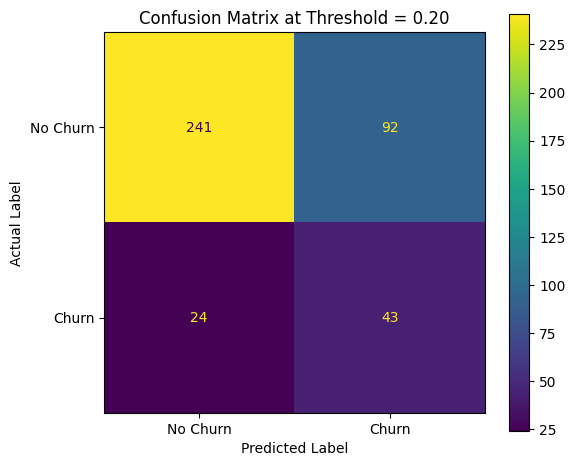

Saved: outputs/figures/confusion_matrix.png

=== Confusion Matrix Interpretation ===
True non-churners correctly not flagged: 241
False alarms flagged for outreach: 92
Churners missed: 24
True churners caught: 43


In [18]:
# ============================================================================
# Section 16: Model Figures
# Saves:
# - outputs/figures/roc_curve.png
# - outputs/figures/precision_recall_curve.png
# - outputs/figures/calibration_curve.png
# - outputs/figures/confusion_matrix.png
# ============================================================================

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, evaluation_results["y_proba"])

roc_fig = go.Figure()

roc_fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode="lines",
    name=f"Logistic Regression AUC = {evaluation_results['test_auc']:.3f}",
))

roc_fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode="lines",
    name="Random classifier",
    line=dict(dash="dash"),
))

roc_fig.update_layout(
    title=f"Churn Prediction Model - ROC Curve (AUC = {evaluation_results['test_auc']:.3f})",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    height=500,
)

roc_fig.write_image(FIGURES_PATH / "roc_curve.png")
roc_fig.show()

print("Saved: outputs/figures/roc_curve.png")


# Precision-recall curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_test,
    evaluation_results["y_proba"],
)

pr_fig = go.Figure()

pr_fig.add_trace(go.Scatter(
    x=recall_vals,
    y=precision_vals,
    mode="lines",
    name=f"Average Precision = {evaluation_results['average_precision']:.3f}",
))

baseline_churn_rate = y_test.mean()

pr_fig.add_hline(
    y=baseline_churn_rate,
    line_dash="dash",
    annotation_text=f"Baseline churn rate = {baseline_churn_rate:.1%}",
)

pr_fig.update_layout(
    title=f"Churn Prediction Model - Precision-Recall Curve (AP = {evaluation_results['average_precision']:.3f})",
    xaxis_title="Recall",
    yaxis_title="Precision",
    height=500,
)

pr_fig.write_image(FIGURES_PATH / "precision_recall_curve.png")
pr_fig.show()

print("Saved: outputs/figures/precision_recall_curve.png")


# Calibration curve
fig, ax = plt.subplots(figsize=(7, 5))

CalibrationDisplay.from_predictions(
    y_test,
    evaluation_results["y_proba"],
    n_bins=10,
    ax=ax,
    name="Logistic Regression",
)

ax.set_title("Churn Prediction Model - Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "calibration_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: outputs/figures/calibration_curve.png")


# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=evaluation_results["confusion_matrix"],
    display_labels=["No Churn", "Churn"],
).plot(ax=ax, values_format="d")

ax.set_title(
    f"Confusion Matrix at Threshold = {evaluation_results['selected_threshold']:.2f}"
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = evaluation_results["confusion_matrix"].ravel()

print("Saved: outputs/figures/confusion_matrix.png")
print("\n=== Confusion Matrix Interpretation ===")
print(f"True non-churners correctly not flagged: {tn}")
print(f"False alarms flagged for outreach: {fp}")
print(f"Churners missed: {fn}")
print(f"True churners caught: {tp}")

**Interpretation:** The ROC curve summarizes ranking performance across all thresholds, while the precision-recall curve is especially useful because churn is less common than non-churn. The calibration curve shows whether predicted probabilities behave like real probabilities. The confusion matrix translates the selected threshold into operational outcomes: churners caught, churners missed, false alarms, and correctly ignored non-churners.

---
## Section 17: Feature Importance

Because the model is logistic regression and the features were standardized, coefficients are directly comparable. Positive coefficients increase predicted churn risk. Negative coefficients reduce predicted churn risk.

This is the most interpretable part of the model: it explains which early patient signals are most associated with 30-day churn.

In [19]:
# ============================================================================
# Section 17: Feature Importance
# ============================================================================

coef_series = pd.Series(
    churn_model.coef_[0],
    index=feature_names,
    name="coefficient",
)

feature_importance = (
    coef_series
    .to_frame()
    .assign(abs_coefficient=lambda x: x["coefficient"].abs())
    .assign(
        direction=lambda x: np.where(
            x["coefficient"] > 0,
            "increases churn risk",
            "reduces churn risk",
        )
    )
    .sort_values("abs_coefficient", ascending=False)
)

display(feature_importance)

feature_importance.to_csv(TABLES_PATH / "feature_importance.csv")
print("Saved optional table: outputs/tables/feature_importance.csv")

feature_importance_plot_df = (
    feature_importance
    .sort_values("coefficient", ascending=True)
    .reset_index()
    .rename(columns={"index": "feature"})
)

importance_fig = go.Figure()

importance_fig.add_trace(go.Bar(
    x=feature_importance_plot_df["coefficient"],
    y=feature_importance_plot_df["feature"],
    orientation="h",
    marker_color=np.where(
        feature_importance_plot_df["coefficient"] >= 0,
        "red",
        "green",
    ),
))

importance_fig.add_vline(x=0, line_dash="dash")

importance_fig.update_layout(
    title=(
        "Which Patient Signals Drive 30-Day Churn Risk?"
        "<br><sup>Red = higher churn risk | Green = lower churn risk</sup>"
    ),
    xaxis_title="Standardized Logistic Regression Coefficient",
    yaxis_title="Feature",
    height=700,
    margin=dict(l=220),
)

importance_fig.write_image(FIGURES_PATH / "feature_importance.png")
importance_fig.show()

print("Saved: outputs/figures/feature_importance.png")

top_risk_increasing_features = feature_importance[
    feature_importance["coefficient"] > 0
].head(3)

top_risk_reducing_features = feature_importance[
    feature_importance["coefficient"] < 0
].head(3)

print("\n=== Top Risk-Increasing Features ===")
display(top_risk_increasing_features)

print("\n=== Top Risk-Reducing Features ===")
display(top_risk_reducing_features)

print("\nImportant interpretation note:")
print(
    "For continuous features, a positive coefficient means higher values increase churn risk. "
    "A negative coefficient means higher values reduce churn risk. "
    "For example, if engagement_score_day7 has a negative coefficient, then low engagement is the risk signal."
)

,coefficient,abs_coefficient,direction
engagement_score_day7,-0.6410,0.6410,reduces churn risk
days_to_first_lab,0.2223,0.2223,increases churn risk
subscription_plan_Standard,0.1884,0.1884,increases churn risk
baseline_testosterone_level,0.1663,0.1663,increases churn risk
prior_telehealth_experience,-0.1543,0.1543,reduces churn risk
treatment_goal_Energy,0.1080,0.1080,increases churn risk
testosterone_tier_Low-Normal,-0.0989,0.0989,reduces churn risk
testosterone_tier_Low,-0.0954,0.0954,reduces churn risk
support_contacts_30d,0.0426,0.0426,increases churn risk
age_group_45-54,0.0287,0.0287,increases churn risk


Saved optional table: outputs/tables/feature_importance.csv


Saved: outputs/figures/feature_importance.png

=== Top Risk-Increasing Features ===


,coefficient,abs_coefficient,direction
days_to_first_lab,0.2223,0.2223,increases churn risk
subscription_plan_Standard,0.1884,0.1884,increases churn risk
baseline_testosterone_level,0.1663,0.1663,increases churn risk



=== Top Risk-Reducing Features ===


,coefficient,abs_coefficient,direction
engagement_score_day7,-0.6410,0.6410,reduces churn risk
prior_telehealth_experience,-0.1543,0.1543,reduces churn risk
testosterone_tier_Low-Normal,-0.0989,0.0989,reduces churn risk



Important interpretation note:
For continuous features, a positive coefficient means higher values increase churn risk. A negative coefficient means higher values reduce churn risk. For example, if engagement_score_day7 has a negative coefficient, then low engagement is the risk signal.


**Interpretation:** The coefficient table should be read directionally. If `days_to_first_lab` has a positive coefficient, longer lab delays increase churn risk. If `engagement_score_day7` has a negative coefficient, higher engagement is protective, which means low engagement is the operational risk signal. For categorical dummy variables, the coefficient is interpreted relative to the dropped reference category.

---
## Section 18: Scoring All Patients

The trained model and fitted scaler are applied to the full 2,000-patient cohort. Each patient receives a predicted churn probability and a risk tier.

Risk tiers are defined as:

- **Low:** `churn_risk_score < 0.25`
- **Medium:** `0.25 <= churn_risk_score <= 0.55`
- **High:** `churn_risk_score > 0.55`

The scored cohort is saved to CSV and written to SQLite as the `scored_cohort` table. This output is required before Phase 4 can begin.

In [20]:
# ============================================================================
# Section 18: Scoring All Patients
# Saves:
# - data/processed/scored_patient_cohort.csv
# - SQLite table scored_cohort in outputs/hone_synthetic.db
# ============================================================================

def score_full_cohort(model, scaler, df: pd.DataFrame, feature_names: list) -> pd.DataFrame:
    """
    Score the full 2,000-patient cohort with predicted churn risk.

    Adds:
    - churn_risk_score
    - churn_risk_tier

    Risk tiers:
    - Low: churn_risk_score < 0.25
    - Medium: 0.25 <= churn_risk_score <= 0.55
    - High: churn_risk_score > 0.55
    """
    modeling_features = [
        "age",
        "baseline_testosterone_level",
        "days_to_first_lab",
        "engagement_score_day7",
        "support_contacts_30d",
        "prior_telehealth_experience",
        "testosterone_tier",
        "treatment_goal",
        "subscription_plan",
        "age_group",
    ]

    categorical_features = [
        "testosterone_tier",
        "treatment_goal",
        "subscription_plan",
        "age_group",
    ]

    scored_df = df.copy()

    X_full_raw = scored_df[modeling_features].copy()

    X_full = pd.get_dummies(
        X_full_raw,
        columns=categorical_features,
        drop_first=True,
        dtype=float,
    )

    X_full = X_full.reindex(columns=feature_names, fill_value=0)

    X_full_scaled = scaler.transform(X_full)

    scored_df["churn_risk_score"] = model.predict_proba(X_full_scaled)[:, 1]

    scored_df["churn_risk_tier"] = np.select(
        [
            scored_df["churn_risk_score"] < 0.25,
            scored_df["churn_risk_score"].between(0.25, 0.55, inclusive="both"),
            scored_df["churn_risk_score"] > 0.55,
        ],
        [
            "Low",
            "Medium",
            "High",
        ],
        default="Medium",
    )

    scored_csv_path = PROJECT_ROOT / "data" / "processed" / "scored_patient_cohort.csv"
    scored_df.to_csv(scored_csv_path, index=False)

    with sqlite3.connect(DB_PATH) as conn:
        scored_df.to_sql(
            "scored_cohort",
            conn,
            if_exists="replace",
            index=False,
        )

    print("=== Full Cohort Scoring Complete ===")
    print(f"Scored cohort shape: {scored_df.shape}")
    print(f"Saved CSV: {scored_csv_path}")
    print(f"Saved SQLite table: scored_cohort in {DB_PATH}")

    print("\n=== Risk Tier Counts ===")
    tier_counts = scored_df["churn_risk_tier"].value_counts().reindex(
        ["Low", "Medium", "High"],
        fill_value=0,
    )
    display(tier_counts.to_frame("patient_count"))

    print("\n=== Risk Tier Summary ===")
    risk_tier_summary = (
        scored_df
        .groupby("churn_risk_tier")
        .agg(
            patient_count=("patient_id", "count"),
            avg_churn_risk_score=("churn_risk_score", "mean"),
            observed_churn_rate=("churned_30d", "mean"),
        )
        .round(4)
        .reindex(["Low", "Medium", "High"])
    )

    display(risk_tier_summary)

    return scored_df


scored_df = score_full_cohort(churn_model, scaler, df, feature_names)

=== Full Cohort Scoring Complete ===
Scored cohort shape: (2000, 19)
Saved CSV: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\data\processed\scored_patient_cohort.csv
Saved SQLite table: scored_cohort in c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\hone_synthetic.db

=== Risk Tier Counts ===


,patient_count
churn_risk_tier,
Low,1594
Medium,388
High,18



=== Risk Tier Summary ===


,patient_count,avg_churn_risk_score,observed_churn_rate
churn_risk_tier,,,
Low,1594,0.1240,0.0910
Medium,388,0.3383,0.4536
High,18,0.5951,0.8889


**Interpretation:** The full cohort now has `churn_risk_score` and `churn_risk_tier` fields. The tier summary should generally show higher observed churn rates as the risk tier increases. Even if the High tier is small, the output is valid as long as every patient is scored and assigned according to the required thresholds.

---
## Section 19: Business Impact Estimation

This section connects the experiment result from Phase 2 with the churn model from Phase 3. The estimate uses the A/B test adherence lift as the assumed intervention effect for the High-risk tier.

The revenue estimate is illustrative only. It uses an assumed `$150/month` subscription value over a 3-month horizon and should not be interpreted as an actual financial forecast.

In [21]:
# ============================================================================
# Section 19: Business Impact Estimation
# ============================================================================

high_risk_patients = scored_df[scored_df["churn_risk_tier"] == "High"].copy()
high_risk_count = len(high_risk_patients)

# Safer fallback:
# If the Phase 2 primary result dictionary exists, use it.
# If not, recompute the experiment absolute lift directly from df.
if "primary" in globals() and isinstance(primary, dict) and "abs_lift" in primary:
    experiment_abs_lift = primary["abs_lift"]
else:
    control_adherence = df.loc[df["experiment_arm"] == "Control", "adhered_90d"].mean()
    treatment_adherence = df.loc[df["experiment_arm"] == "Treatment", "adhered_90d"].mean()
    experiment_abs_lift = treatment_adherence - control_adherence

assumed_monthly_subscription_value = 150
horizon_months = 3

estimated_additional_retained_patients = high_risk_count * experiment_abs_lift

estimated_retained_revenue = (
    estimated_additional_retained_patients
    * assumed_monthly_subscription_value
    * horizon_months
)

business_impact_summary = pd.DataFrame([
    {
        "high_risk_patient_count": high_risk_count,
        "experiment_absolute_lift": experiment_abs_lift,
        "estimated_additional_retained_patients": estimated_additional_retained_patients,
        "assumed_monthly_subscription_value": assumed_monthly_subscription_value,
        "horizon_months": horizon_months,
        "illustrative_retained_revenue_estimate": estimated_retained_revenue,
    }
])

display(business_impact_summary.round(3))

business_impact_summary.to_csv(
    TABLES_PATH / "business_impact_estimate.csv",
    index=False,
)

print("=== Business Impact Estimation ===")
print(f"High-risk patients: {high_risk_count:,}")
print(f"Experiment absolute lift used: {experiment_abs_lift:.4f} ({experiment_abs_lift:.1%})")
print(f"Estimated additional retained patients: {estimated_additional_retained_patients:.1f}")

print(
    "\nIllustrative retained revenue estimate using an assumed "
    f"${assumed_monthly_subscription_value}/month subscription value:"
)
print(
    f"${estimated_additional_retained_patients:.1f} patients × "
    f"${assumed_monthly_subscription_value}/month × {horizon_months} months "
    f"= ${estimated_retained_revenue:,.0f}"
)

print("\nSaved optional table: outputs/tables/business_impact_estimate.csv")
print("Note: This is an illustrative estimate, not a real financial forecast.")

,high_risk_patient_count,experiment_absolute_lift,estimated_additional_retained_patients,assumed_monthly_subscription_value,horizon_months,illustrative_retained_revenue_estimate
0,18,0.0970,1.7460,150,3,785.7000


=== Business Impact Estimation ===
High-risk patients: 18
Experiment absolute lift used: 0.0970 (9.7%)
Estimated additional retained patients: 1.7

Illustrative retained revenue estimate using an assumed $150/month subscription value:
$1.7 patients × $150/month × 3 months = $786

Saved optional table: outputs/tables/business_impact_estimate.csv
Note: This is an illustrative estimate, not a real financial forecast.


**Interpretation:** This estimate translates the model into a product-facing prioritization case. The logic is: identify High-risk patients, apply the experimentally measured adherence lift as the assumed intervention effect, and estimate the number of additional retained or adherent patients. The exact phrase “Illustrative retained revenue estimate using an assumed $150/month subscription value” is used to make clear that this is a portfolio assumption, not a real pricing claim.

---
## Section 20: Phase 3 Output Validation

This final Phase 3 validation confirms that all required model outputs exist before moving to Phase 4. The validation checks saved figures, the scored CSV, the SQLite `scored_cohort` table, row counts, required score columns, and availability of the final model metrics.

Do not start Phase 4 until the final line says: `Phase 3 is complete and validated. Ready for Phase 4.`

In [22]:
# ============================================================================
# Section 20: Phase 3 Output Validation
# ============================================================================

required_phase3_figures = [
    FIGURES_PATH / "roc_curve.png",
    FIGURES_PATH / "precision_recall_curve.png",
    FIGURES_PATH / "calibration_curve.png",
    FIGURES_PATH / "confusion_matrix.png",
    FIGURES_PATH / "feature_importance.png",
]

required_phase3_data = [
    PROJECT_ROOT / "data" / "processed" / "scored_patient_cohort.csv",
]

optional_phase3_tables = [
    TABLES_PATH / "feature_importance.csv",
    TABLES_PATH / "business_impact_estimate.csv",
]

validation_rows = []

for path in required_phase3_figures:
    validation_rows.append({
        "artifact_type": "required_figure",
        "artifact_name": path.name,
        "path": str(path),
        "exists": path.is_file(),
    })

for path in required_phase3_data:
    validation_rows.append({
        "artifact_type": "required_data",
        "artifact_name": path.name,
        "path": str(path),
        "exists": path.is_file(),
    })

for path in optional_phase3_tables:
    validation_rows.append({
        "artifact_type": "optional_table",
        "artifact_name": path.name,
        "path": str(path),
        "exists": path.is_file(),
    })

# Check scored CSV
scored_csv_path = PROJECT_ROOT / "data" / "processed" / "scored_patient_cohort.csv"

if scored_csv_path.is_file():
    scored_csv = pd.read_csv(scored_csv_path)
    scored_csv_row_count = scored_csv.shape[0]
    scored_csv_has_score = "churn_risk_score" in scored_csv.columns
    scored_csv_has_tier = "churn_risk_tier" in scored_csv.columns
    high_risk_patient_count = (
        scored_csv["churn_risk_tier"].eq("High").sum()
        if scored_csv_has_tier
        else 0
    )
else:
    scored_csv = pd.DataFrame()
    scored_csv_row_count = 0
    scored_csv_has_score = False
    scored_csv_has_tier = False
    high_risk_patient_count = 0

# Check SQLite scored_cohort table
with sqlite3.connect(DB_PATH) as conn:
    table_check = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='scored_cohort';",
        conn,
    )

    scored_cohort_exists = not table_check.empty

    if scored_cohort_exists:
        scored_cohort_rows = pd.read_sql_query(
            "SELECT COUNT(*) AS row_count FROM scored_cohort;",
            conn,
        )["row_count"].iloc[0]
    else:
        scored_cohort_rows = 0

validation_rows.extend([
    {
        "artifact_type": "required_check",
        "artifact_name": "scored_csv_has_2000_rows",
        "path": str(scored_csv_path),
        "exists": scored_csv_row_count == 2000,
    },
    {
        "artifact_type": "required_check",
        "artifact_name": "scored_csv_has_churn_risk_score",
        "path": str(scored_csv_path),
        "exists": scored_csv_has_score,
    },
    {
        "artifact_type": "required_check",
        "artifact_name": "scored_csv_has_churn_risk_tier",
        "path": str(scored_csv_path),
        "exists": scored_csv_has_tier,
    },
    {
        "artifact_type": "required_sqlite_table",
        "artifact_name": "scored_cohort",
        "path": str(DB_PATH),
        "exists": scored_cohort_exists,
    },
    {
        "artifact_type": "required_check",
        "artifact_name": "scored_cohort_has_2000_rows",
        "path": str(DB_PATH),
        "exists": scored_cohort_rows == 2000,
    },
    {
        "artifact_type": "required_check",
        "artifact_name": "test_auc_roc_available",
        "path": "evaluation_results",
        "exists": isinstance(evaluation_results, dict) and "test_auc" in evaluation_results,
    },
    {
        "artifact_type": "required_check",
        "artifact_name": "selected_threshold_available",
        "path": "evaluation_results",
        "exists": isinstance(evaluation_results, dict) and "selected_threshold" in evaluation_results,
    },
])

phase3_validation_df = pd.DataFrame(validation_rows)
display(phase3_validation_df)

required_checks_pass = phase3_validation_df[
    phase3_validation_df["artifact_type"] != "optional_table"
]["exists"].all()

optional_checks_pass = phase3_validation_df[
    phase3_validation_df["artifact_type"] == "optional_table"
]["exists"].all()

model_quality_checks = {
    "cv_auc_roc_mean_at_least_0_70": model_training_summary["cv_auc_mean"] >= 0.70,
    "test_auc_roc_at_least_0_70": evaluation_results["test_auc"] >= 0.70,
    "selected_threshold_recall_at_least_0_60": evaluation_results["recall"] >= 0.60,
    "at_least_one_high_risk_patient": high_risk_patient_count > 0,
}

model_quality_pass = all(model_quality_checks.values())

print("=== Phase 3 Validation Summary ===")
print(f"Required Phase 3 artifact checks passed: {required_checks_pass}")
print(f"Optional Phase 3 tables exist: {optional_checks_pass}")
print(f"Model quality checks passed: {model_quality_pass}")
print(f"Scored CSV row count: {scored_csv_row_count}")
print(f"SQLite scored_cohort row count: {scored_cohort_rows}")
print(f"High-risk patient count: {high_risk_patient_count}")

print("\n=== Final Model Metrics ===")
print(f"CV AUC-ROC mean: {model_training_summary['cv_auc_mean']:.4f}")
print(f"CV AUC-ROC standard deviation: {model_training_summary['cv_auc_std']:.4f}")
print(f"Test AUC-ROC: {evaluation_results['test_auc']:.4f}")
print(f"Average precision: {evaluation_results['average_precision']:.4f}")
print(f"Selected threshold: {evaluation_results['selected_threshold']:.2f}")
print(f"Precision: {evaluation_results['precision']:.4f}")
print(f"Recall: {evaluation_results['recall']:.4f}")
print(f"F1: {evaluation_results['f1']:.4f}")

print("\n=== Model Quality Checks ===")
for check_name, passed in model_quality_checks.items():
    print(f"{check_name}: {passed}")

if not required_checks_pass:
    missing_required = phase3_validation_df[
        (phase3_validation_df["artifact_type"] != "optional_table")
        & (~phase3_validation_df["exists"])
    ]["artifact_name"].tolist()

    print("\nPhase 3 validation failed.")
    print(f"Missing or failed required artifact checks: {missing_required}")
    print("Do not start Phase 4 yet.")

elif not model_quality_pass:
    failed_quality_checks = [
        check_name
        for check_name, passed in model_quality_checks.items()
        if not passed
    ]

    print("\nPhase 3 validation failed.")
    print(f"Failed model quality checks: {failed_quality_checks}")
    print("Do not start Phase 4 yet.")

else:
    print("\nPhase 3 is complete and validated. Ready for Phase 4.")

,artifact_type,artifact_name,path,exists
0,required_figure,roc_curve.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
1,required_figure,precision_recall_curve.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
2,required_figure,calibration_curve.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
3,required_figure,confusion_matrix.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
4,required_figure,feature_importance.png,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
5,required_data,scored_patient_cohort.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
6,optional_table,feature_importance.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
7,optional_table,business_impact_estimate.csv,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
8,required_check,scored_csv_has_2000_rows,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True
9,required_check,scored_csv_has_churn_risk_score,c:\Users\Aditi Patil\OneDrive\Documents\Master...,True


=== Phase 3 Validation Summary ===
Required Phase 3 artifact checks passed: True
Optional Phase 3 tables exist: True
Model quality checks passed: True
Scored CSV row count: 2000
SQLite scored_cohort row count: 2000
High-risk patient count: 18

=== Final Model Metrics ===
CV AUC-ROC mean: 0.7771
CV AUC-ROC standard deviation: 0.0495
Test AUC-ROC: 0.7577
Average precision: 0.4271
Selected threshold: 0.20
Precision: 0.3185
Recall: 0.6418
F1: 0.4257

=== Model Quality Checks ===
cv_auc_roc_mean_at_least_0_70: True
test_auc_roc_at_least_0_70: True
selected_threshold_recall_at_least_0_60: True
at_least_one_high_risk_patient: True

Phase 3 is complete and validated. Ready for Phase 4.


**Phase 3 completion note:** If every required validation check passes, the churn model has been trained, evaluated, used to score all 2,000 patients, and saved to both CSV and SQLite. The notebook is then ready for Phase 4 SQL cohort analysis.

---
## Section 21: SQL Cohort Analysis

This section uses SQL to summarize experiment outcomes, segment adherence patterns, identify high-risk patients for operational outreach, and analyze rolling enrollment trends. The SQL files are stored separately in the `sql/` directory and executed against the project SQLite database using `pandas.read_sql_query`.

In [23]:
# ============================================================================
# Section 21: SQL Cohort Analysis Setup
# ============================================================================

import pandas as pd
import sqlite3
from pathlib import Path

DB_PATH = PROJECT_ROOT / "outputs" / "hone_synthetic.db"
SQL_DIR = PROJECT_ROOT / "sql"
TABLE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"

TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Database exists:", DB_PATH.exists())
print("SQL directory exists:", SQL_DIR.exists())
print("Output table directory exists:", TABLE_OUTPUT_DIR.exists())

Database exists: True
SQL directory exists: True
Output table directory exists: True


In [24]:
# ============================================================================
# Required SQLite Table Checks
# ============================================================================

def check_required_tables(db_path, required_tables):
    """
    Confirm that required SQLite tables exist before running Phase 4 SQL queries.
    """
    with sqlite3.connect(db_path) as conn:
        existing_tables = pd.read_sql_query(
            """
            SELECT name
            FROM sqlite_master
            WHERE type = 'table';
            """,
            conn
        )["name"].tolist()

    missing_tables = [table for table in required_tables if table not in existing_tables]

    print("Existing SQLite tables:")
    print(existing_tables)

    if missing_tables:
        raise ValueError(f"Missing required tables: {missing_tables}")

    print("All required Phase 4 tables exist.")

check_required_tables(
    DB_PATH,
    required_tables=["patient_cohort", "scored_cohort"]
)

Existing SQLite tables:
['patient_cohort', 'scored_cohort']
All required Phase 4 tables exist.


In [25]:
# ============================================================================
# Enrollment Date Format Check
# ============================================================================

with sqlite3.connect(DB_PATH) as conn:
    enrollment_date_check = pd.read_sql_query(
        """
        SELECT enrollment_date
        FROM patient_cohort
        LIMIT 10;
        """,
        conn
    )

display(enrollment_date_check)

,enrollment_date
0,2024-10-01
1,2024-05-19
2,2024-11-04
3,2024-08-31
4,2024-01-27
5,2024-12-21
6,2024-09-26
7,2024-10-06
8,2024-02-06
9,2024-05-24


In [26]:
# ============================================================================
# SQL Execution Helper
# ============================================================================

def run_sql_file(sql_file_path, db_path, output_csv_path):
    """
    Read a SQL file, execute it against the SQLite database, display the result,
    and save the result as a CSV file.
    """
    with open(sql_file_path, "r", encoding="utf-8") as file:
        query = file.read()

    with sqlite3.connect(db_path) as conn:
        result_df = pd.read_sql_query(query, conn)

    display(result_df)

    result_df.to_csv(output_csv_path, index=False)

    print(f"Saved result to: {output_csv_path}")
    print(f"Result shape: {result_df.shape}")

    return result_df

### 21.1 Cohort Summary by Experiment Arm

**Business question:** How do the main experiment KPIs compare between the Control and Treatment groups?

This query summarizes patient count, 90-day adherence, 30-day churn, 90-day appointment completion, and average day-7 engagement by experiment arm.

In [27]:
sql_cohort_summary = run_sql_file(
    sql_file_path=SQL_DIR / "cohort_summary.sql",
    db_path=DB_PATH,
    output_csv_path=TABLE_OUTPUT_DIR / "sql_cohort_summary.csv"
)

,experiment_arm,patient_count,adherence_rate_90d,churn_rate_30d,appointment_completion_rate_90d,avg_engagement_score_day7
0,Control,1000,0.5290,0.1810,0.6420,5.9600
1,Treatment,1000,0.6260,0.1560,0.7050,5.9300


Saved result to: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_cohort_summary.csv
Result shape: (2, 6)


**Interpretation:** The cohort summary compares Control and Treatment patients across the main experiment and engagement KPIs. The Treatment arm should show stronger adherence and lower churn if the personalized check-in intervention is performing as expected.

**Cohort Summary: Treatment performed better than Control***

Your cohort_summary.sql output is:

Control:
patient_count = 1000
adherence_rate_90d = 0.5290
churn_rate_30d = 0.1810
appointment_completion_rate_90d = 0.6420
avg_engagement_score_day7 = 5.96

Treatment:
patient_count = 1000
adherence_rate_90d = 0.6260
churn_rate_30d = 0.1560
appointment_completion_rate_90d = 0.7050
avg_engagement_score_day7 = 5.93
What this means

The Treatment arm had higher 90-day adherence:

Treatment adherence: 62.6%
Control adherence: 52.9%
Absolute lift: +9.7 percentage points

It also had lower 30-day churn:

Treatment churn: 15.6%
Control churn: 18.1%
Absolute reduction: -2.5 percentage points

And it had higher appointment completion:

Treatment appointment completion: 70.5%
Control appointment completion: 64.2%
Absolute lift: +6.3 percentage points

The average day-7 engagement score is basically the same:

Control: 5.96
Treatment: 5.93

That is actually good. It means the Treatment group did not simply have “better” patients at baseline. The groups look balanced, but Treatment still performed better on adherence and appointment completion.

Business interpretation

The personalized check-in intervention appears operationally useful. It improves adherence and appointment completion while reducing churn, without relying on a higher-engagement Treatment group.

### 21.2 Segment-Level Adherence

**Business question:** Which patient segments show the strongest or weakest 90-day adherence by experiment arm?

This query breaks adherence down by age group, treatment goal, and experiment arm so that patient segments can be compared operationally.

In [28]:
sql_segment_adherence = run_sql_file(
    sql_file_path=SQL_DIR / "segment_adherence.sql",
    db_path=DB_PATH,
    output_csv_path=TABLE_OUTPUT_DIR / "sql_segment_adherence.csv"
)

,age_group,treatment_goal,experiment_arm,patient_count,adherence_rate_90d
0,25-34,Body Composition,Control,81,0.5309
1,25-34,Body Composition,Treatment,80,0.5625
2,25-34,Energy,Control,122,0.5328
3,25-34,Energy,Treatment,123,0.6423
4,25-34,General Wellness,Control,37,0.6216
5,25-34,General Wellness,Treatment,37,0.5676
6,25-34,Libido,Control,101,0.4752
7,25-34,Libido,Treatment,100,0.6400
8,35-44,Body Composition,Control,99,0.5354
9,35-44,Body Composition,Treatment,99,0.5556


Saved result to: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_segment_adherence.csv
Result shape: (32, 5)


**Interpretation:** The segment adherence table shows how adherence varies across patient age groups and treatment goals. These segment-level differences can help identify where personalized engagement is strongest and where additional intervention design may be needed.

Segment Adherence: Treatment helps most in some patient groups

Your segment_adherence.sql output returned:

32 rows x 5 columns

That is exactly expected:

4 age groups x 4 treatment goals x 2 experiment arms = 32 rows

The strongest segment improvements were:

35-44, Energy:
Control adherence = 54.05%
Treatment adherence = 72.30%
Lift = +18.25 percentage points

35-44, Libido:
Control adherence = 46.62%
Treatment adherence = 64.66%
Lift = +18.04 percentage points

25-34, Libido:
Control adherence = 47.52%
Treatment adherence = 64.00%
Lift = +16.48 percentage points

25-34, Energy:
Control adherence = 53.28%
Treatment adherence = 64.23%
Lift = +10.95 percentage points

There are also a few small or negative segment differences:

25-34, General Wellness:
Control = 62.16%
Treatment = 56.76%
Lift = -5.40 percentage points

45-54, Body Composition:
Control = 55.36%
Treatment = 52.63%
Lift = -2.73 percentage points

55-65, Libido:
Control = 71.43%
Treatment = 66.67%
Lift = -4.76 percentage points

But be careful: some of those smaller segments have very small sample sizes. For example, the 55-65 groups have very few patients, so their rates can swing a lot from just one or two patients.

Business interpretation

The intervention seems strongest for patients whose treatment goals are Energy and Libido, especially in the 25-34 and 35-44 age groups.

That makes sense for the product story: patients with Energy or Libido goals may respond better to personalized messaging because those goals are more directly tied to perceived treatment progress and motivation.

For portfolio language, say this:

Segment-level SQL analysis suggests the strongest adherence lift appears among Energy and Libido patients, especially in the 25-44 age range. These findings are exploratory and should be used to guide targeted rollout hypotheses rather than treated as confirmatory causal claims.

### 21.3 Highest-Risk Patients for Outreach

**Business question:** Which patients should the care team prioritize based on predicted churn risk?

This query ranks the top 50 patients by churn risk score and assigns each patient a recommended action using rule-based business logic.

In [29]:
sql_high_risk_patients = run_sql_file(
    sql_file_path=SQL_DIR / "high_risk_patients.sql",
    db_path=DB_PATH,
    output_csv_path=TABLE_OUTPUT_DIR / "sql_high_risk_patients.csv"
)

,patient_id,churn_risk_score,churn_risk_tier,treatment_goal,testosterone_tier,age_group,days_to_first_lab,engagement_score_day7,recommended_action
0,P000480,0.7045,High,General Wellness,Borderline,35-44,44,1.3000,Send personalized care-team check-in immediately
1,P000104,0.6869,High,Libido,Borderline,25-34,52,1.8000,Send personalized care-team check-in immediately
2,P000250,0.6368,High,Libido,Borderline,45-54,26,0.8000,Send personalized care-team check-in immediately
3,P000025,0.6318,High,Energy,Borderline,35-44,20,0.3000,Send personalized care-team check-in immediately
4,P000840,0.6056,High,Energy,Borderline,45-54,5,0.4000,Send personalized care-team check-in immediately
5,P000933,0.5960,High,Energy,Borderline,35-44,32,1.2000,Send personalized care-team check-in immediately
6,P000891,0.5958,High,Energy,Borderline,25-34,28,1.3000,Send personalized care-team check-in immediately
7,P001474,0.5936,High,Energy,Borderline,55-65,5,0.5000,Send personalized care-team check-in immediately
8,P001677,0.5928,High,Libido,Borderline,45-54,11,0.2000,Send personalized care-team check-in immediately
9,P000019,0.5753,High,Energy,Borderline,45-54,6,1.0000,Send personalized care-team check-in immediately


Saved result to: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_high_risk_patients.csv
Result shape: (50, 9)


**Interpretation:** The high-risk patient table converts the churn model into an actionable care-team outreach list. Because the scored cohort contains 18 High-risk patients, the top 50 list includes all High-risk patients first, followed by the next-highest Medium-risk patients, each with a recommended action based on risk tier and early engagement signals.

High-Risk Patients: SQL successfully converts the model into an outreach list

Your high_risk_patients.sql output returned:

50 rows x 9 columns

That is correct.

From the top 50:

18 patients are High risk
32 patients are Medium risk

Recommended action counts:

Send personalized care-team check-in immediately: 17 patients
Prioritize lab completion reminder: 1 patient
Send automated educational message at day 14: 32 patients

Risk score range in the top 50:

Highest churn risk score: 0.7045
Lowest score in top 50: 0.4520

The highest-risk patient shown is:

P000480
churn_risk_score = 0.7045
churn_risk_tier = High
treatment_goal = General Wellness
testosterone_tier = Borderline
age_group = 35-44
days_to_first_lab = 44
engagement_score_day7 = 1.3
recommended_action = Send personalized care-team check-in immediately
What this means

The SQL query is doing exactly what it should. It takes the model score from Phase 3 and turns it into a care-team work queue.

Most High-risk patients have very low engagement, so the recommended action is:

Send personalized care-team check-in immediately

Only one High-risk patient triggered the lab-delay-specific action:

Prioritize lab completion reminder

The remaining 32 rows are Medium-risk patients because the query asks for the top 50 patients overall, not only High-risk patients.

Business interpretation

This is one of the strongest Phase 4 outputs because it connects the model to real operational action. You are not just predicting churn; you are showing how a care team could prioritize outreach.

Use this wording:

The high-risk patient query operationalizes the churn model by ranking patients by predicted dropout risk and assigning recommended care-team actions. The output includes all 18 High-risk patients followed by the next-highest Medium-risk patients, creating a practical outreach queue for patient success or clinical operations teams.

### 21.4 Rolling 7-Day Enrollment Trend

**Business question:** How did patient enrollment volume trend over time?

This query calculates rolling 7-day enrollment counts to show short-term changes in cohort intake across the synthetic enrollment year.

In [30]:
sql_rolling_enrollment = run_sql_file(
    sql_file_path=SQL_DIR / "rolling_enrollment.sql",
    db_path=DB_PATH,
    output_csv_path=TABLE_OUTPUT_DIR / "sql_rolling_enrollment.csv"
)

,enrollment_date,rolling_7d_enrollments
0,2024-01-01,6
1,2024-01-02,13
2,2024-01-03,17
3,2024-01-04,23
4,2024-01-05,26
...,...,...
357,2024-12-26,36
358,2024-12-27,42
359,2024-12-28,43
360,2024-12-29,39


Saved result to: c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_rolling_enrollment.csv
Result shape: (362, 2)


**Interpretation:** The rolling enrollment table shows short-term enrollment volume using a trailing 7-day window. This helps reveal intake spikes and operational demand patterns across the synthetic enrollment year.

Rolling Enrollment: The date logic worked correctly

Your rolling_enrollment.sql output returned:

362 rows x 2 columns

That is okay.

It does not need to be exactly 365 rows because the query returns unique enrollment dates that actually appear in the data. If no patients enrolled on a few dates, those dates will not appear.

The first rows show:

2024-01-01: 6
2024-01-02: 13
2024-01-03: 17
2024-01-04: 23
2024-01-05: 26

Near the end, it shows:

2024-12-26: 36
2024-12-27: 42
2024-12-28: 43
2024-12-29: 39
2024-12-30: 40
What this means

The rolling 7-day query works. It is counting how many patients enrolled in the current date plus the prior six days.

Also, your enrollment date format check showed dates like:

2024-10-01
2024-05-19
2024-11-04

So SQLite’s DATE() function is working correctly.

Business interpretation

This query shows short-term enrollment volume trends. It can help operations understand when patient intake is heavier and when staffing or onboarding capacity may need to scale.

### 21.5 Phase 4 SQL Output Validation

This final Phase 4 validation confirms that all SQL queries ran successfully and that the required SQL output tables were saved to `outputs/tables/`.

In [31]:
# ============================================================================
# Phase 4 SQL Output Validation
# ============================================================================

expected_sql_outputs = [
    TABLE_OUTPUT_DIR / "sql_cohort_summary.csv",
    TABLE_OUTPUT_DIR / "sql_segment_adherence.csv",
    TABLE_OUTPUT_DIR / "sql_high_risk_patients.csv",
    TABLE_OUTPUT_DIR / "sql_rolling_enrollment.csv"
]

print("Phase 4 SQL Output Validation")
print("=" * 40)

for output_path in expected_sql_outputs:
    print(f"{output_path}: {output_path.exists()}")

print("\nDataFrame shapes:")
print(f"sql_cohort_summary: {sql_cohort_summary.shape}")
print(f"sql_segment_adherence: {sql_segment_adherence.shape}")
print(f"sql_high_risk_patients: {sql_high_risk_patients.shape}")
print(f"sql_rolling_enrollment: {sql_rolling_enrollment.shape}")

all_sql_outputs_exist = all(output_path.exists() for output_path in expected_sql_outputs)

shape_checks = {
    "cohort_summary_has_2_rows": sql_cohort_summary.shape[0] == 2,
    "segment_adherence_has_rows": sql_segment_adherence.shape[0] > 0,
    "high_risk_patients_has_50_rows": sql_high_risk_patients.shape[0] == 50,
    "rolling_enrollment_has_rows": sql_rolling_enrollment.shape[0] > 0,
}

print("\nShape checks:")
for check_name, passed in shape_checks.items():
    print(f"{check_name}: {passed}")

if not all_sql_outputs_exist:
    raise ValueError("One or more required SQL output CSV files were not created.")

if not all(shape_checks.values()):
    raise ValueError("One or more Phase 4 SQL result shape checks failed.")

print("\nPhase 4 is complete and validated. Ready for Phase 5.")

Phase 4 SQL Output Validation
c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_cohort_summary.csv: True
c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_segment_adherence.csv: True
c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_high_risk_patients.csv: True
c:\Users\Aditi Patil\OneDrive\Documents\Master's Projects\Health-AB-testing-retention\outputs\tables\sql_rolling_enrollment.csv: True

DataFrame shapes:
sql_cohort_summary: (2, 6)
sql_segment_adherence: (32, 5)
sql_high_risk_patients: (50, 9)
sql_rolling_enrollment: (362, 2)

Shape checks:
cohort_summary_has_2_rows: True
segment_adherence_has_rows: True
high_risk_patients_has_50_rows: True
rolling_enrollment_has_rows: True

Phase 4 is complete and validated. Ready for Phase 5.


Phase 4 SQL analysis successfully translated the experiment, segmentation, and churn model outputs into operational cohort views. The cohort summary confirmed that Treatment patients had higher 90-day adherence, lower 30-day churn, and higher appointment completion than Control patients. Segment analysis showed that the strongest adherence gains appeared among Energy and Libido patients, especially in the 25-44 age range. The high-risk patient query converted churn scores into a ranked outreach list with recommended actions, including all 18 High-risk patients and the next-highest Medium-risk patients. The rolling enrollment query confirmed that enrollment trends can be tracked using a SQLite-compatible 7-day trailing count.

**Phase 4 completion note:** If every validation check passes, the SQL cohort analysis layer is complete. The project now includes experiment KPI summaries, segment-level adherence analysis, a ranked high-risk patient outreach list, and rolling 7-day enrollment trends.

---